# ex007_PHT3D_07

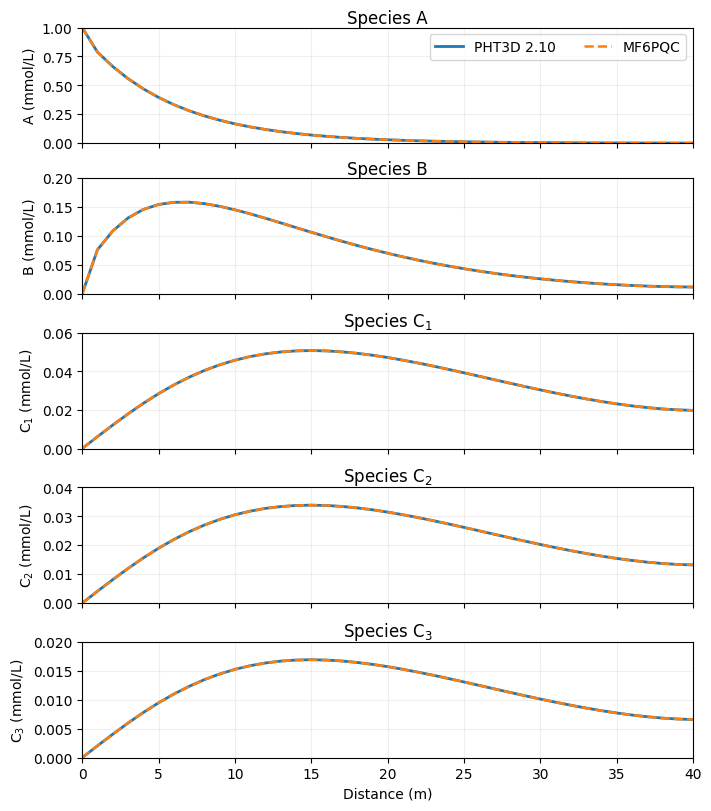

,RMSE,Unit
Variable,,
S_a,4.86716e-09,mmol/L
S_b,2.32663e-09,mmol/L
S_c,3.02806e-08,mmol/L
S_cc,3.36685e-08,mmol/L
S_ccc,6.9237e-08,mmol/L


In [1]:
import pandas as pd
from IPython.display import display

comparison_rows = []
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = CASE_DIR / "output"
results = np.load(OUTPUT_DIR / "results.npy")
expected_headings = ["S_a", "S_b", "S_c", "S_cc", "S_ccc"]
reference = np.load(INPUT_DIR / "PHT3D_07_results.npy")
x_m = reference["x_m"]
official = np.vstack([reference[name] for name in ("s_a", "s_b", "s_c", "s_cc", "s_ccc")])
mf6pqc = results[-1] * 1000.0
official = official * 1000.0
species_titles = ["Species A", "Species B", "Species C$_1$", "Species C$_2$", "Species C$_3$"]
ylabels = ["A", "B", "C$_1$", "C$_2$", "C$_3$"]
ylimits = [(0.0, 1.0), (0.0, 0.2), (0.0, 0.06), (0.0, 0.04), (0.0, 0.02)]
for name, a, b in zip(expected_headings, mf6pqc, official, strict=True):
    comparison_rows.append(
        {"Variable": name, "RMSE": np.sqrt(np.mean((a - b) ** 2)), "Unit": "mmol/L"}
    )
fig, axes = plt.subplots(5, 1, figsize=(7, 8), sharex=True, constrained_layout=True)
for index, ax in enumerate(axes):
    ax.plot(x_m, official[index], color="tab:blue", linewidth=2.0, label="PHT3D 2.10")
    ax.plot(x_m, mf6pqc[index], "--", color="tab:orange", linewidth=1.8, label="MF6PQC")
    ax.set_title(species_titles[index], pad=3)
    ax.set_ylabel(f"{ylabels[index]} (mmol/L)")
    ax.set_xlim(0.0, 40.0)
    ax.set_ylim(*ylimits[index])
    ax.grid(alpha=0.2)
axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("Distance (m)")
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.set_index("Variable")
display(comparison.style.format({"RMSE": "{:.6g}"}).set_uuid("ex007_1"))